<a href="https://colab.research.google.com/github/winston-k/Wi20260413/blob/main/py2111h_knn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbourhood Example

In [1]:
#
#
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# reading the iris dataset from the web, UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# Assign colum names to the dataset
nam = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

# Read dataset to pandas dataframe
dataset = pd.read_csv(url, names=nam)

In [3]:
dataset.head()

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
dataset.shape

(150, 5)

In [5]:
type(dataset)

pandas.core.frame.DataFrame

In [6]:
# features and labels
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values
type(y)

numpy.ndarray

In [7]:
# spliting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=1)

In [8]:
# normalization
from sklearn.preprocessing import StandardScaler
print(X_test)
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(X_test)

[[5.8 4.  1.2 0.2]
 [5.1 2.5 3.  1.1]
 [6.6 3.  4.4 1.4]
 [5.4 3.9 1.3 0.4]
 [7.9 3.8 6.4 2. ]
 [6.3 3.3 4.7 1.6]
 [6.9 3.1 5.1 2.3]
 [5.1 3.8 1.9 0.4]
 [4.7 3.2 1.6 0.2]
 [6.9 3.2 5.7 2.3]
 [5.6 2.7 4.2 1.3]
 [5.4 3.9 1.7 0.4]
 [7.1 3.  5.9 2.1]
 [6.4 3.2 4.5 1.5]
 [6.  2.9 4.5 1.5]
 [4.4 3.2 1.3 0.2]
 [5.8 2.6 4.  1.2]
 [5.6 3.  4.5 1.5]
 [5.4 3.4 1.5 0.4]
 [5.  3.2 1.2 0.2]
 [5.5 2.6 4.4 1.2]
 [5.4 3.  4.5 1.5]
 [6.7 3.  5.  1.7]
 [5.  3.5 1.3 0.3]
 [7.2 3.2 6.  1.8]
 [5.7 2.8 4.1 1.3]
 [5.5 4.2 1.4 0.2]
 [5.1 3.8 1.5 0.3]
 [6.1 2.8 4.7 1.2]
 [6.3 2.5 5.  1.9]]
[[-0.04622511  2.3720024  -1.48043619 -1.31466572]
 [-0.89033581 -1.240184   -0.4597716  -0.15276803]
 [ 0.91847283 -0.03612186  0.33407864  0.2345312 ]
 [-0.52857408  2.13118998 -1.4237326  -1.05646624]
 [ 2.48610699  1.89037755  1.46815041  1.00912966]
 [ 0.5567111   0.68631542  0.50418941  0.49273069]
 [ 1.28023456  0.20469056  0.73100376  1.39642889]
 [-0.89033581  1.89037755 -1.08351107 -1.05646624]
 [-1.37268478  0.4455

In [9]:
# construction of the model, training that
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=19)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [10]:
# testing the model
y_pred = classifier.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  0  0]
 [ 0 11  2]
 [ 0  0  6]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.85      0.92        13
 Iris-virginica       0.75      1.00      0.86         6

       accuracy                           0.93        30
      macro avg       0.92      0.95      0.92        30
   weighted avg       0.95      0.93      0.94        30



In [11]:
error = []

# Calculating error for K values between 1 and 39
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Mean Error')

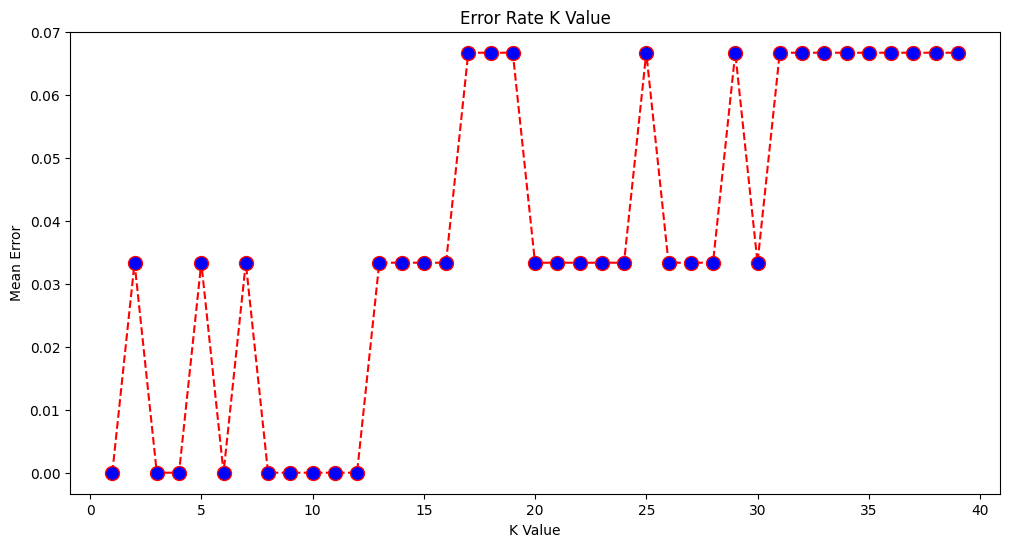

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [13]:
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [14]:
y_pred = classifier.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



### Practices
1. Try the KNN with k=3,5,7 on your iris dataset without any normalization.
2. Is it more accurate or less?
3. Use celebs2.csv datafile, allocate 70% of data samples for training and 30% for testing, develop a classifier that would be able to classify celebrities into 2 gender classes, 1=Female, 2=Male based on Height and Weight features.
4. Try k=1,5,7, compare the results.

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Re-split the data without normalization
X_train_unnormalized, X_test_unnormalized, y_train_unnormalized, y_test_unnormalized = train_test_split(X, y, test_size=0.2, random_state=1)

k_values = [3, 5, 7]

print("--- KNN without Normalization ---")
for k in k_values:
    print(f"\nEvaluating KNN with k = {k}")
    knn_unnormalized = KNeighborsClassifier(n_neighbors=k)
    knn_unnormalized.fit(X_train_unnormalized, y_train_unnormalized)
    y_pred_unnormalized = knn_unnormalized.predict(X_test_unnormalized)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test_unnormalized, y_pred_unnormalized))
    print("Classification Report:")
    print(classification_report(y_test_unnormalized, y_pred_unnormalized))

print("\n--- Comparison ---")
print("With normalization (k=3, previous output): Accuracy was 1.00")
print("Without normalization (k=3): Observe the accuracy above.")
print("Without normalization (k=5): Observe the accuracy above.")
print("Without normalization (k=7): Observe the accuracy above.")
print("In general, normalization often helps improve accuracy by preventing features with larger ranges from dominating the distance calculations. You can compare the 'accuracy' score in the classification reports above with the 1.00 accuracy obtained previously with normalization and k=3.")

--- KNN without Normalization ---

Evaluating KNN with k = 3
Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Evaluating KNN with k = 5
Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighte

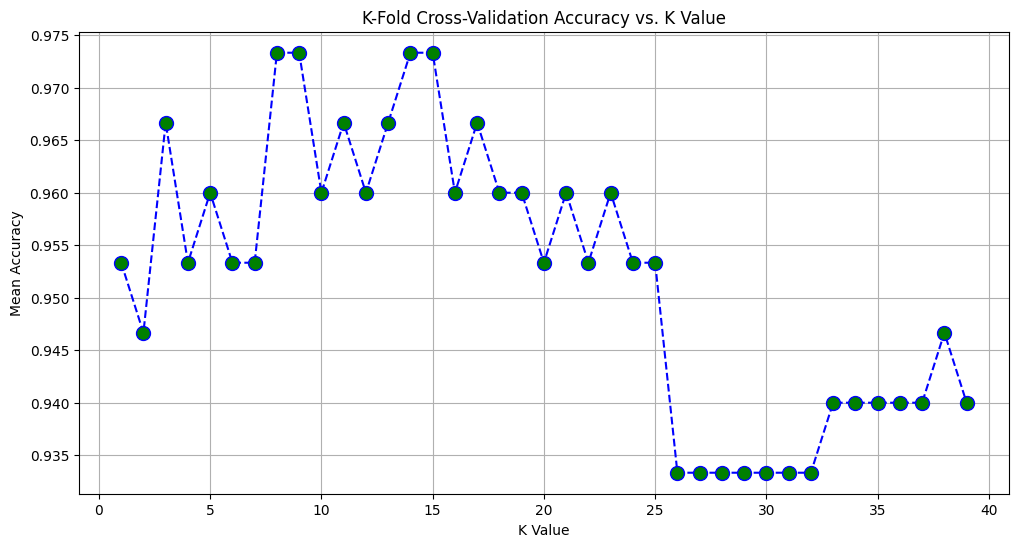

The optimal K value based on k-fold cross-validation is: 8 with a mean accuracy of 0.9733


In [16]:
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define the range of K values to evaluate
k_values_cv = list(range(1, 40))

# Prepare for k-fold cross-validation
# Using the normalized data (X_train, y_train) for a more robust evaluation
kf = KFold(n_splits=10, shuffle=True, random_state=1)

# Store mean accuracy for each K
mean_accuracies = []

for k in k_values_cv:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    # Perform 10-fold cross-validation
    scores = cross_val_score(knn_cv, X, y, cv=kf, scoring='accuracy')
    mean_accuracies.append(scores.mean())

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(k_values_cv, mean_accuracies, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='green', markersize=10)
plt.title('K-Fold Cross-Validation Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.show()

# Find the optimal K
optimal_k_index = np.argmax(mean_accuracies)
optimal_k = k_values_cv[optimal_k_index]
print(f"The optimal K value based on k-fold cross-validation is: {optimal_k} with a mean accuracy of {mean_accuracies[optimal_k_index]:.4f}")

In [17]:
%matplotlib inline
from google.colab import drive

drive.mount('/content/drive')



Mounted at /content/drive


In [18]:
import os
# List files in the specified directory to verify the path
path_to_check = '/content/drive/My Drive/Emeritus/Wi20260418/Module2-8/'
if os.path.exists(path_to_check):
    print(f"Contents of {path_to_check}:")
    for item in os.listdir(path_to_check):
        print(item)
else:
    print(f"Directory not found: {path_to_check}")


Contents of /content/drive/My Drive/Emeritus/Wi20260418/Module2-8/:
knn1.ipynb
Iris.xlsx
celebs2.csv


In [19]:
# Load the dataset
file_path = "/content/drive/My Drive/Emeritus/Wi20260418/Module2-8/celebs2.csv"

dataset = pd.read_csv(file_path)



In [20]:
dataset.shape

(90, 3)

In [21]:
dataset.describe()

,177.8,52.095,1
count,90.000000,90.000000,90.000000
mean,172.930889,67.965100,1.511111
std,10.955349,19.035505,0.502677
min,154.900000,44.847000,1.000000
25%,162.600000,52.548000,1.000000
50%,172.700000,61.834500,2.000000
75%,181.000000,79.728000,2.000000
max,198.000000,149.943000,2.000000


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Assuming the dataset has columns: Height, Weight, Gender
# Based on dataset.describe(), the columns are likely unnamed but in this order.
# Let's rename them for clarity if they aren't explicitly named in the loaded dataset.
# The dataset was loaded in a previous cell as 'dataset'.
# Checking the first few rows or column names would confirm, but based on describe(),
# the first column is Height, second is Weight, and third is Gender.

# It seems the dataset was loaded without headers, so the first row became the header.
# Let's reload it with proper column names if needed, or just work with iloc.
# For now, let's assume the columns are in the order [Height, Weight, Gender].
# Checking the 'dataset' variable content from previous output, the columns are indeed 177.8, 52.095, 1 (numeric).
# Let's re-read the CSV with specified names if not already done, or just use iloc based on the describe output.

# Given the dataset output from 'dataset.describe()', it seems the first row became the header.
# The actual data starts from the second row and the columns are in order 'Height', 'Weight', 'Gender'.
# Let's explicitly define the features X and target y.

# Make a copy to avoid SettingWithCopyWarning if original DataFrame is a slice
df_celebs = dataset.copy()

# Assuming the columns are in order: Height, Weight, Gender
# The original problem statement indicates '1=Female, 2=Male' for gender.
# Based on the 'describe()' output, the third column (index 2) is the gender.
# The first two columns are Height and Weight.
X_celebs = df_celebs.iloc[:, :2].values  # Features: Height, Weight
y_celebs = df_celebs.iloc[:, 2].values   # Target: Gender

print("Shape of features (X_celebs):", X_celebs.shape)
print("Shape of target (y_celebs):", y_celebs.shape)

# Split the data into training and testing sets (70% train, 30% test)
X_train_celebs, X_test_celebs, y_train_celebs, y_test_celebs = train_test_split(
    X_celebs, y_celebs, test_size=0.3, random_state=42, stratify=y_celebs
)

print("\nTraining features shape:", X_train_celebs.shape)
print("Testing features shape:", X_test_celebs.shape)

# Standardize the features (important for KNN)
scaler = StandardScaler()
X_train_celebs_scaled = scaler.fit_transform(X_train_celebs)
X_test_celebs_scaled = scaler.transform(X_test_celebs)

# Define the k values to test
k_values = [1, 5, 7]

print("\n--- KNN Classification for Celebs2 Dataset ---")
for k in k_values:
    print(f"\nEvaluating KNN with k = {k}")
    knn_classifier = KNeighborsClassifier(n_neighbors=k)
    knn_classifier.fit(X_train_celebs_scaled, y_train_celebs)
    y_pred_celebs = knn_classifier.predict(X_test_celebs_scaled)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test_celebs, y_pred_celebs))
    print("Classification Report:")
    print(classification_report(y_test_celebs, y_pred_celebs))

print("\n--- Comparison of results for k=1, 5, 7 ---")
print("Observe the 'accuracy' and other metrics in the classification reports above for each k value.")
print("A higher accuracy generally indicates a better performing model. Also, check precision, recall, and f1-score for each class (1=Female, 2=Male) to understand performance across genders.")
print("You may notice how the choice of k affects the balance between bias and variance, potentially leading to different performance metrics.")

Shape of features (X_celebs): (90, 2)
Shape of target (y_celebs): (90,)

Training features shape: (63, 2)
Testing features shape: (27, 2)

--- KNN Classification for Celebs2 Dataset ---

Evaluating KNN with k = 1
Confusion Matrix:
[[12  1]
 [ 1 13]]
Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.92      0.92        13
           2       0.93      0.93      0.93        14

    accuracy                           0.93        27
   macro avg       0.93      0.93      0.93        27
weighted avg       0.93      0.93      0.93        27


Evaluating KNN with k = 5
Confusion Matrix:
[[12  1]
 [ 1 13]]
Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.92      0.92        13
           2       0.93      0.93      0.93        14

    accuracy                           0.93        27
   macro avg       0.93      0.93      0.93        27
weighted avg       0.93      0.93      0.